# Minimal Audio Analysis Starter

このノートブックは、初期フェーズの最小音声解析用です。

目的:
- WAV ファイルを読み込む
- 基本情報を確認する
- 波形を表示する
- スペクトルを表示する
- スペクトログラムを表示する

想定:
- 対象ファイルは `research/data/raw/` に置く
- 最初は単一ファイルを観察する
- 後で比較用ノートブックに発展させる


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
from scipy.io import wavfile

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True


In [2]:
# 対象ファイルを必要に応じて変更する
audio_path = Path("../data/raw/reference/sample.wav")

if not audio_path.exists():
    raise FileNotFoundError(
        f"Input audio file was not found: {audio_path}. "
        "Place a WAV file under research/data/raw/reference/ and update audio_path."
    )

sample_rate, audio = wavfile.read(audio_path)

# ステレオの場合は解析用にモノラルへ平均化する
if audio.ndim == 2:
    audio = audio.mean(axis=1)

audio = audio.astype(np.float64)

# 整数 PCM の場合を想定して正規化する
peak = np.max(np.abs(audio))
if peak > 0:
    audio = audio / peak

duration_sec = len(audio) / sample_rate
time_axis = np.arange(len(audio)) / sample_rate

print(f"file: {audio_path}")
print(f"sample_rate: {sample_rate} Hz")
print(f"samples: {len(audio)}")
print(f"duration: {duration_sec:.3f} sec")
print(f"min/max: {audio.min():.3f} / {audio.max():.3f}")


file: ../data/raw/reference/sample.wav
sample_rate: 16000 Hz
samples: 16000
duration: 1.000 sec
min/max: -1.000 / 1.000


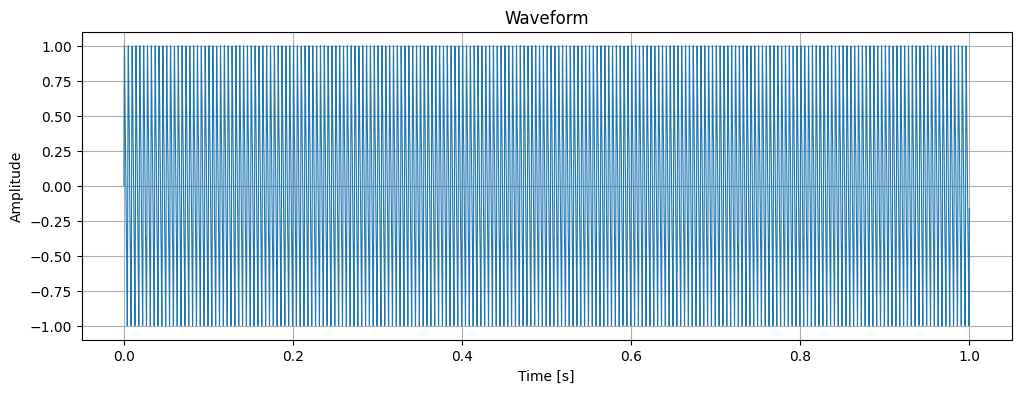

In [3]:
fig, ax = plt.subplots()
ax.plot(time_axis, audio, linewidth=0.8)
ax.set_title("Waveform")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Amplitude")
plt.show()


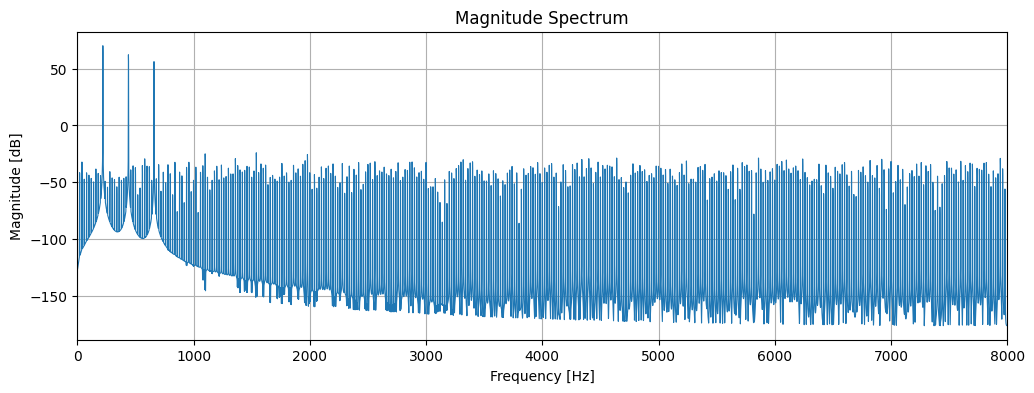

In [4]:
fft_size = min(len(audio), 16384)
windowed = audio[:fft_size] * np.hanning(fft_size)
spectrum = np.fft.rfft(windowed)
frequencies = np.fft.rfftfreq(fft_size, d=1 / sample_rate)
magnitude_db = 20 * np.log10(np.maximum(np.abs(spectrum), 1e-12))

fig, ax = plt.subplots()
ax.plot(frequencies, magnitude_db, linewidth=0.8)
ax.set_title("Magnitude Spectrum")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Magnitude [dB]")
ax.set_xlim(0, min(sample_rate / 2, 8000))
plt.show()


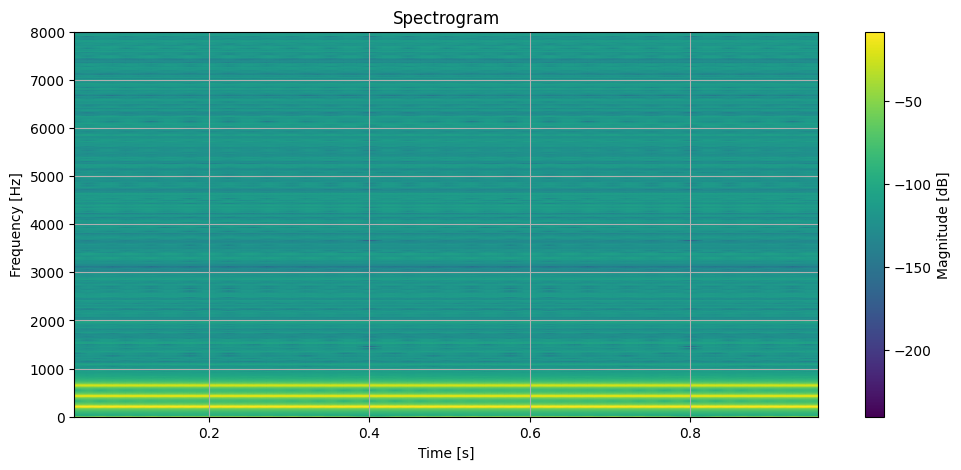

In [5]:
frequencies, times, spectrogram = signal.spectrogram(
    audio,
    fs=sample_rate,
    window="hann",
    nperseg=1024,
    noverlap=768,
    scaling="spectrum",
    mode="magnitude",
)

spectrogram_db = 20 * np.log10(np.maximum(spectrogram, 1e-12))

fig, ax = plt.subplots(figsize=(12, 5))
image = ax.pcolormesh(times, frequencies, spectrogram_db, shading="gouraud")
ax.set_title("Spectrogram")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
ax.set_ylim(0, min(sample_rate / 2, 8000))
fig.colorbar(image, ax=ax, label="Magnitude [dB]")
plt.show()


## Next Steps

次の候補:
- 基本周波数の観察を追加する
- フォルマント推定を試す
- 複数ファイル比較用にテンプレート化する
- Web プロトタイプで生成した音声をここで読む
